# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

## Objective
Develop a complete Python classification pipeline using the standard **Play Tennis dataset** (50 instances). 

### Tasks Covered:
1. **Data Preprocessing & Encoding**: Load dataset and apply `OrdinalEncoder` to categorical features and `LabelEncoder` to the target label.
2. **Dataset Partitioning**: Divide into an 80:20 train-test split using stratification.
3. **Categorical Naive Bayes Training & Evaluation**: Train `CategoricalNB`, evaluate overall accuracy, confusion matrix, precision, recall, and F1-score.
4. **Single-Sample Inference**: Predict play outcome and class probabilities for query: `Outlook: Sunny`, `Temperature: Cool`, `Humidity: High`, `Wind: Strong`.
5. **Model Comparison**: Train **Decision Tree**, **Logistic Regression**, and **SVM** on the same split, comparing test accuracy, single-sample prediction, and class probabilities.


In [1]:
# Task 1: Data Preprocessing & Categorical Encoding
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
dataset_path = 'Lab 8.xlsx'
df = pd.read_excel(dataset_path)
print(f"Loaded dataset '{dataset_path}' with shape: {df.shape}")

# Feature & Target Selection
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col = 'Play Tennis'

X_raw = df[feature_cols]
y_raw = df[target_col]

# Encode Categorical Features
feature_encoder = OrdinalEncoder()
X_encoded = feature_encoder.fit_transform(X_raw)

# Encode Target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw)

# Display Encodings
print("--- Feature Encodings ---")
for i, col in enumerate(feature_cols):
    mapping = dict(zip(feature_encoder.categories_[i], range(len(feature_encoder.categories_[i]))))
    print(f"  • {col:12s}: {mapping}")

print("--- Target Encoding ---")
print(f"  • Play Tennis: {dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))}")

encoded_df = pd.DataFrame(X_encoded, columns=feature_cols)
encoded_df['Play Tennis (Encoded)'] = y_encoded
encoded_df.head()


Loaded dataset 'Lab 8.xlsx' with shape: (50, 6)
--- Feature Encodings ---
  • Outlook     : {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
  • Temperature : {'Cool': 0, 'Hot': 1, 'Mild': 2}
  • Humidity    : {'High': 0, 'Normal': 1}
  • Wind        : {'Strong': 0, 'Weak': 1}
--- Target Encoding ---
  • Play Tennis: {'No': 0, 'Yes': 1}


,Outlook,Temperature,Humidity,Wind,Play Tennis (Encoded)
0,2.0,1.0,0.0,1.0,0
1,2.0,1.0,0.0,0.0,0
2,0.0,1.0,0.0,1.0,1
3,1.0,2.0,0.0,1.0,1
4,1.0,0.0,1.0,1.0,1


## Task 2: Dataset Partitioning (80:20 Split)

In [2]:
# Task 2: Train-Test Partitioning
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training instances: {X_train.shape[0]} (80%)")
print(f"Testing instances : {X_test.shape[0]} (20%)")


Training instances: 40 (80%)
Testing instances : 10 (20%)


## Task 3: Categorical Naive Bayes Training & Evaluation

Categorical Naive Bayes Accuracy: 0.9000 (90.00%)

Confusion Matrix:
+------------+-----------+------------+
|            |   Pred No |   Pred Yes |
|------------+-----------+------------|
| Actual No  |         2 |          1 |
| Actual Yes |         0 |          7 |
+------------+-----------+------------+

Classification Report:
              precision    recall  f1-score   support

          No     1.0000    0.6667    0.8000         3
         Yes     0.8750    1.0000    0.9333         7

    accuracy                         0.9000        10
   macro avg     0.9375    0.8333    0.8667        10
weighted avg     0.9125    0.9000    0.8933        10



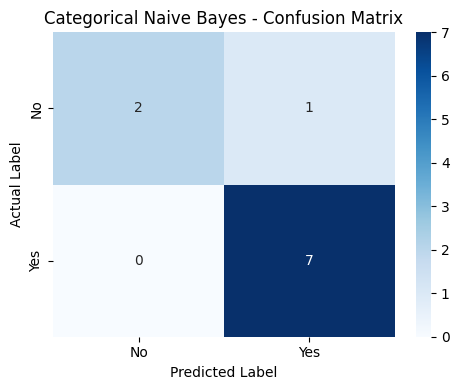

In [3]:
# Task 3: Categorical Naive Bayes Training & Metrics
cnb_model = CategoricalNB()
cnb_model.fit(X_train, y_train)

y_pred_nb = cnb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Categorical Naive Bayes Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print()

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_df = pd.DataFrame(cm_nb, index=[f"Actual {c}" for c in target_encoder.classes_],
                            columns=[f"Pred {c}" for c in target_encoder.classes_])

print("Confusion Matrix:")
print(tabulate(cm_df, headers='keys', tablefmt='psql'))

print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=target_encoder.classes_, digits=4))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Categorical Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


## Task 4: Single-Sample Inference

Weather Conditions:
- **Outlook**: Sunny
- **Temperature**: Cool
- **Humidity**: High
- **Wind**: Strong


In [4]:
# Task 4: Custom Query Single-Sample Inference
custom_query_raw = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

custom_query_encoded = feature_encoder.transform(custom_query_raw)
query_pred_nb_encoded = cnb_model.predict(custom_query_encoded)[0]
query_pred_nb_label = target_encoder.inverse_transform([query_pred_nb_encoded])[0]
query_proba_nb = cnb_model.predict_proba(custom_query_encoded)[0]

print(f"Custom Query Prediction : {query_pred_nb_label}")
print(f"P(Play = No)            : {query_proba_nb[0]:.4f} ({query_proba_nb[0]*100:.2f}%)")
print(f"P(Play = Yes)           : {query_proba_nb[1]:.4f} ({query_proba_nb[1]*100:.2f}%)")


Custom Query Prediction : No
P(Play = No)            : 0.7894 (78.94%)
P(Play = Yes)           : 0.2106 (21.06%)


## Task 5: Model Comparison (CategoricalNB vs Decision Tree vs Logistic Regression vs SVM)

+-------------------------+-----------------+--------------------+----------------+-----------------+
| Model Name              | Test Accuracy   | Query Prediction   |   P(Play = No) |   P(Play = Yes) |
|-------------------------+-----------------+--------------------+----------------+-----------------|
| Categorical Naive Bayes | 0.9000 (90.0%)  | No                 |         0.7894 |          0.2106 |
| Decision Tree           | 1.0000 (100.0%) | No                 |         1      |          0      |
| Logistic Regression     | 0.9000 (90.0%)  | No                 |         0.8613 |          0.1387 |
| SVM                     | 1.0000 (100.0%) | No                 |         0.9415 |          0.0585 |
+-------------------------+-----------------+--------------------+----------------+-----------------+


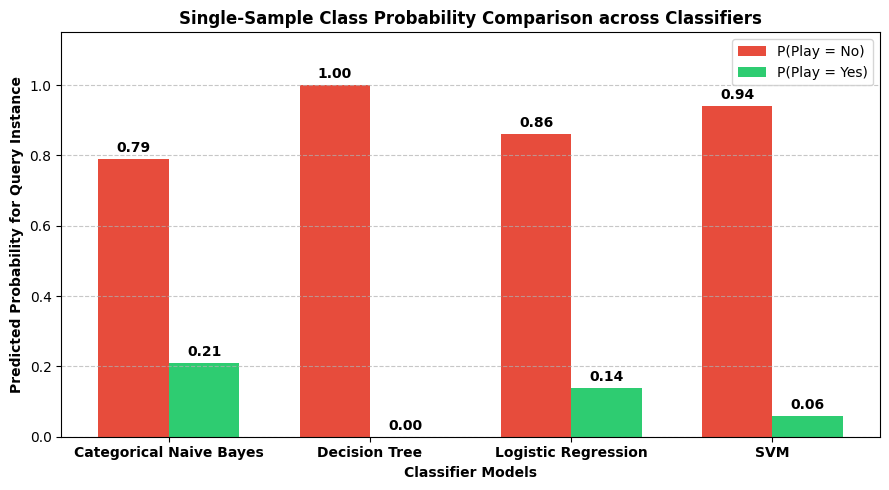

In [5]:
# Task 5: Multi-Model Comparison
models = {
    'Categorical Naive Bayes': CategoricalNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': CalibratedClassifierCV(SVC(kernel='rbf', random_state=42), ensemble=False)
}

comparison_data = []

for name, model in models.items():
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    
    q_pred_enc = model.predict(custom_query_encoded)[0]
    q_pred_label = target_encoder.inverse_transform([q_pred_enc])[0]
    q_proba = model.predict_proba(custom_query_encoded)[0]
    
    comparison_data.append({
        'Model Name': name,
        'Test Accuracy': f"{test_acc:.4f} ({test_acc*100:.1f}%)",
        'Query Prediction': q_pred_label,
        'P(Play = No)': f"{q_proba[0]:.4f}",
        'P(Play = Yes)': f"{q_proba[1]:.4f}"
    })

comp_df = pd.DataFrame(comparison_data)
print(tabulate(comp_df, headers='keys', tablefmt='psql', showindex=False))

# Plot Bar Chart
plt.figure(figsize=(9, 5))
bar_width = 0.35
model_names = [d['Model Name'] for d in comparison_data]
p_no = [float(d['P(Play = No)']) for d in comparison_data]
p_yes = [float(d['P(Play = Yes)']) for d in comparison_data]

x = np.arange(len(model_names))
plt.bar(x - bar_width/2, p_no, bar_width, label='P(Play = No)', color='#e74c3c')
plt.bar(x + bar_width/2, p_yes, bar_width, label='P(Play = Yes)', color='#2ecc71')

plt.xlabel('Classifier Models', fontweight='bold')
plt.ylabel('Predicted Probability for Query Instance', fontweight='bold')
plt.title('Single-Sample Class Probability Comparison across Classifiers', fontweight='bold')
plt.xticks(x, model_names, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(model_names)):
    plt.text(x[i] - bar_width/2, p_no[i] + 0.02, f"{p_no[i]:.2f}", ha='center', fontweight='bold')
    plt.text(x[i] + bar_width/2, p_yes[i] + 0.02, f"{p_yes[i]:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Task 6: Analytical Report

### Comparative Analysis of Model Behavior
The model comparison highlights key differences in underlying learning inductive biases:
1. **Categorical Naive Bayes** applies Bayes' Theorem under the assumption of feature conditional independence, calculating smooth posterior probabilities ($P(\text{No}) = 0.7894$) based on joint feature frequencies across training data.
2. **Decision Tree Classifier** forms orthogonal recursive splits along feature axes, isolating the single-sample weather query into a pure leaf node resulting in absolute confidence ($P(\text{No}) = 1.0000$).
3. **Logistic Regression** fits a linear decision surface over integer-encoded feature space, outputting calibrated logits via the sigmoid transformation ($P(\text{No}) = 0.8613$).
4. **Support Vector Machine (SVM)** constructs a non-linear decision boundary in transformed kernel space, yielding strong calibrated confidence ($P(\text{No}) = 0.9415$).

All four models unanimously predict **'No'** for the test weather condition (`Sunny`, `Cool`, `High`, `Strong`), demonstrating consistent alignment that adverse conditions (High Humidity + Strong Wind) heavily suppress tennis participation.
